# 3. Learned ratios and unbinned Asimov fits


    Train process-to-S and systematic-variation density ratios with the pinned
    NSBI toolkit, construct the interference model, and compare learned and
    analytical unbinned Asimov scans. Run notebooks 1–2 first.

    Here NSBI ratio estimation uses classifiers trained with cross entropy; it
    does not require a separate normalizing-flow density estimator because the
    S reference can be sampled directly.

### Runtime and persistent run

In Colab, choose **Runtime → Change runtime type → GPU** for notebooks 2–3.
Both PyTorch training and JAX likelihood fits use the GPU when available.
`JAX_BACKEND = "auto"` detects the Colab NVIDIA GPU; choose `"gpu"` to require it,
or `"cpu"` for an explicit CPU run. Setup installs matching JAX/JAXlib and CUDA 12
plugin packages, then checks double-precision JIT computation and gradients on
the selected device before training. GPU initialization failures are reported
instead of silently switching to CPU. Restart the runtime once when switching
from the previous CPU-only setup or after a JAX plugin error.
Keep the same run name: saved samples and trained networks are reused.
The source checkout lives in the temporary runtime; **datasets, checkpoints,
workspace files, and results live in Google Drive**. Use the same `RUN_NAME`
and `MODE` in every notebook. Set `MODE = "smoke"` for a short workflow check;
the production default generates five million events **per sample**.
Use `CONFIG_OVERRIDES` to change a computational budget without editing source,
for example `{"quadrature_per_process": 500_000, "epochs": 150}`. Use the same
overrides in all five notebooks, and choose a new `RUN_NAME` when changing them.

This repository may be private. Grant Colab access when opening it from GitHub.
For the runtime download, either save a GitHub fine-grained token with **Contents:
read** access to this repository as the Colab secret `GITHUB_TOKEN`, or enter it
in the hidden prompt. The token is used only in a Python HTTP header and is not
written into files, Git remotes, shell arguments, or notebook output. Alternatively,
upload a repository ZIP to `/content/poodemo_source.zip`; no token is then needed.
An existing `/content/poodemo` checkout is reused. Delete that checkout to fetch
new source after updating the repository; your Drive run is separate.
For this NI-only revision, use the new default `RUN_NAME = "demo-ni-v1"`.
If you ran an earlier version, start a fresh Colab runtime (or refresh the
temporary source checkout and restart the runtime) before proceeding. Existing
run manifests from the earlier model are incompatible and are not reused.

In [1]:
import os
import sys
from pathlib import Path

RUN_NAME = "demo-ni-v1"
MODE = os.environ.get("POODEMO_MODE", "production")  # production or smoke
CONFIG_OVERRIDES = {}  # e.g. {"quadrature_per_process": 500_000, "epochs": 150}
JAX_BACKEND = os.environ.get("POODEMO_JAX_BACKEND", "auto")  # auto, gpu, or cpu

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    import subprocess
    requested_backend = JAX_BACKEND.strip().lower()
    if requested_backend not in ("auto", "gpu", "cpu"):
        raise ValueError("JAX_BACKEND must be auto, gpu, or cpu")
    selected_backend = requested_backend
    if requested_backend == "auto":
        try:
            gpu_probe = subprocess.run(["nvidia-smi", "--query-gpu=name", "--format=csv,noheader"],
                                       capture_output=True, text=True, timeout=10)
            gpu_present = gpu_probe.returncode == 0 and bool(gpu_probe.stdout.strip())
        except (OSError, subprocess.TimeoutExpired):
            gpu_present = False
        selected_backend = "gpu" if gpu_present else "cpu"
    # CUDA-only selection fails visibly if initialization fails. Keep PyTorch's
    # CUDA visibility and avoid JAX reserving most GPU memory before training.
    jax_platform = "cuda" if selected_backend == "gpu" else "cpu"
    os.environ["JAX_PLATFORMS"] = jax_platform
    os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false")
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
    ROOT = Path(os.environ.get("POODEMO_ROOT", f"/content/drive/MyDrive/poodemo/runs/{RUN_NAME}"))
    REPO_DIR = Path("/content/poodemo")
    if not (REPO_DIR / "pyproject.toml").exists():
        import getpass
        import io
        import shutil
        import tarfile
        import tempfile
        import urllib.error
        import urllib.request
        import zipfile

        uploaded_zip = Path("/content/poodemo_source.zip")
        if uploaded_zip.exists():
            archive_bytes = uploaded_zip.read_bytes()
            archive_kind = "zip"
        else:
            archive_url = "https://api.github.com/repos/rafaellopesdesa/poodemo/tarball/main"

            def fetch_source(token=None):
                headers = {"Accept": "application/vnd.github+json", "User-Agent": "poodemo-colab"}
                if token:
                    headers["Authorization"] = "Bearer " + token
                request = urllib.request.Request(archive_url, headers=headers)
                with urllib.request.urlopen(request, timeout=180) as response:
                    return response.read()

            try:
                archive_bytes = fetch_source()
            except urllib.error.HTTPError as error:
                if error.code not in (401, 403, 404):
                    raise RuntimeError(f"Repository download failed (HTTP {error.code}).") from None
                token = None
                try:
                    from google.colab import userdata
                    token = userdata.get("GITHUB_TOKEN")
                except Exception:
                    pass
                if not token:
                    token = getpass.getpass("GitHub token with read access to poodemo: ").strip()
                if not token:
                    raise RuntimeError("Upload /content/poodemo_source.zip or provide read access.")
                try:
                    archive_bytes = fetch_source(token)
                except urllib.error.HTTPError as auth_error:
                    raise RuntimeError(f"Repository download failed (HTTP {auth_error.code}); check token access.") from None
                finally:
                    token = None
            archive_kind = "tar"

        # Validate archive paths and reject links before extracting the source.
        with tempfile.TemporaryDirectory(prefix="poodemo-source-") as temp:
            staging = Path(temp).resolve()

            def safe_destination(name):
                destination = (staging / name).resolve()
                if not destination.is_relative_to(staging):
                    raise RuntimeError("Unsafe path in source archive.")
                return destination

            if archive_kind == "zip":
                with zipfile.ZipFile(io.BytesIO(archive_bytes)) as archive:
                    for entry in archive.infolist():
                        safe_destination(entry.filename)
                        if (entry.external_attr >> 16) & 0o170000 == 0o120000:
                            raise RuntimeError("Symbolic links are not supported in the source ZIP.")
                    archive.extractall(staging)
            else:
                with tarfile.open(fileobj=io.BytesIO(archive_bytes), mode="r:gz") as archive:
                    for entry in archive.getmembers():
                        safe_destination(entry.name)
                        if not (entry.isfile() or entry.isdir()):
                            raise RuntimeError("Links and special files are not supported in the source archive.")
                    archive.extractall(staging)
            candidates = [p.parent for p in staging.rglob("pyproject.toml") if (p.parent / "poodemo").is_dir()]
            if len(candidates) != 1:
                raise RuntimeError("The uploaded archive must contain one poodemo repository checkout.")
            shutil.copytree(candidates[0], REPO_DIR, dirs_exist_ok=True)
        del archive_bytes

    if os.environ.get("POODEMO_SKIP_INSTALL") != "1":
        from importlib.metadata import version, PackageNotFoundError
        # JAX discovers every installed plugin, even when selecting CPU.
        # Retain already-matched CUDA 12 packages when rerunning GPU setup.
        remove_plugins = []
        for package in ("jax-cuda12-plugin", "jax-cuda12-pjrt", "jax-cuda13-plugin", "jax-cuda13-pjrt"):
            try:
                installed_version = version(package)
            except PackageNotFoundError:
                continue
            if not (selected_backend == "gpu" and package.startswith("jax-cuda12-") and installed_version == "0.5.3"):
                remove_plugins.append(package)
        if remove_plugins:
            subprocess.check_call([sys.executable, "-m", "pip", "uninstall", "-y", "-q", *remove_plugins])
        gpu_requirements = (["jax==0.5.3", "jaxlib==0.5.3",
                             "jax-cuda12-plugin[with-cuda]==0.5.3", "jax-cuda12-pjrt==0.5.3"]
                            if selected_backend == "gpu" else [])
        # Resolve with the base requirements so PyTorch's CUDA dependencies are
        # considered together with JAX's. Avoid blanket --upgrade changes.
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "-r",
                               str(REPO_DIR / "requirements-colab.txt"), *gpu_requirements])
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "-e", str(REPO_DIR)])

        # Check the live notebook kernel before any expensive network training.
        import jax
        import jaxlib
        import jax.numpy as jnp
        if jax.__version__ != "0.5.3" or jaxlib.__version__ != "0.5.3":
            raise RuntimeError("JAX packages are stale in this kernel. Restart the runtime and rerun setup.")
        if selected_backend == "gpu":
            for package in ("jax-cuda12-plugin", "jax-cuda12-pjrt"):
                if version(package) != "0.5.3":
                    raise RuntimeError(f"{package} must match JAX 0.5.3. Restart the runtime and rerun setup.")
        jax.config.update("jax_platforms", jax_platform)
        jax.config.update("jax_enable_x64", True)
        try:
            jax_devices = jax.devices()
            if not jax_devices or any(device.platform != selected_backend for device in jax_devices):
                raise RuntimeError(f"Expected {selected_backend} devices; found {jax_devices}")
            probe_value, probe_gradient = jax.jit(jax.value_and_grad(lambda x: jnp.sum(x*x)))(
                jnp.asarray([1., 2., 3.], dtype=jnp.float64))
            probe_gradient.block_until_ready()
            if (float(probe_value) != 14. or list(probe_gradient) != [2., 4., 6.]
                    or probe_gradient.dtype != jnp.float64
                    or any(device.platform != selected_backend for device in probe_gradient.devices())):
                raise RuntimeError("JAX double-precision value/gradient check failed")
        except Exception as error:
            raise RuntimeError(
                f"JAX {selected_backend} startup failed. Select a Colab GPU runtime if requesting GPU, "
                "then restart the runtime and rerun setup. Use JAX_BACKEND='cpu' only for an intentional CPU run."
            ) from error
        print(f"JAX {jax.__version__} / jaxlib {jaxlib.__version__}: backend={selected_backend}, {jax_devices}; float64 JIT/gradient OK")

    # A new editable install is not activated in an already-running kernel.
    # Expose the inner package directly, including after a failed import cached
    # the outer /content/poodemo checkout as a namespace package.
    import importlib
    source_root = str(REPO_DIR.resolve())
    if source_root in sys.path:
        sys.path.remove(source_root)
    sys.path.insert(0, source_root)
    importlib.invalidate_caches()
    cached_package = sys.modules.get("poodemo")
    cached_file = getattr(cached_package, "__file__", None)
    expected_init = REPO_DIR / "poodemo" / "__init__.py"
    if cached_package is not None and (cached_file is None or Path(cached_file).resolve() != expected_init.resolve()):
        for module_name in list(sys.modules):
            if module_name == "poodemo" or module_name.startswith("poodemo."):
                del sys.modules[module_name]
else:
    # Locally: pip install -r requirements-colab.txt && pip install -e .
    ROOT = Path(os.environ.get("POODEMO_ROOT", str(Path.home() / "poodemo-runs" / RUN_NAME)))
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "poodemo" / "pipeline.py").exists():
            sys.path.insert(0, str(candidate))
            break

ROOT.mkdir(parents=True, exist_ok=True)
print(f"Run directory: {ROOT}")
print(f"Mode: {MODE}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
JAX 0.5.3 / jaxlib 0.5.3: backend=gpu, [CudaDevice(id=0)]; float64 JIT/gradient OK
Run directory: /content/drive/MyDrive/poodemo/runs/demo-ni-v1
Mode: production


In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from poodemo.pipeline import create_run

run = create_run(ROOT, mode=MODE, overrides=CONFIG_OVERRIDES)
plt.rcParams.update({"figure.figsize": (7, 4.5), "axes.grid": True, "grid.alpha": 0.2})
display(pd.Series(run.config, name="configuration"))

,configuration
schema_version,3
mode,production
seed,20261006
toolkit_commit,fc09848fc6540fd32310faebbe9db6eea7ecd17b
n_per_sample,5000000
generation_chunk,250000
preselection_train_cap,1000000
ratio_train_cap,2000000
epochs,100
patience,20


### Density ratios and the physical model

For the fixed selected phase space, set \(q=p_S^{\rm sel}\), and learn
\(r_j=p_j^{\rm sel}/q\) for the other processes. Shape ratios and physical
yields are distinct. At the nominal nuisance value \(\alpha_{NI}=0\),
\[
\frac{D(x;\mu)}{q(x)}
=(\mu-\sqrt\mu)\lambda_S
 +\sqrt\mu\lambda_{SBI}r_{SBI}(x)
 +(1-\sqrt\mu)\lambda_Br_B(x)
 +\lambda_{NI}r_{NI}(x),
\]
where every \(\lambda\) is now a **selected** yield.

We also train the NI up/down variation-to-nominal ratios. There are five
ratio tasks: SBI/S, B/S, NI/S, NI_up/NI, and NI_down/NI. The production
three-member ensembles therefore contain fifteen ratio networks, plus
the separate preselection network. Only NI is morphed; S, B, and SBI
retain their nominal templates. The workspace parameters are
\((\mu,\alpha_{NI})\).

The nuisance interpolation is the toolkit's exponential–polynomial
interpolation. A standard-normal auxiliary measurement supplies
\[
L_{\rm aux}(\alpha_{NI})\propto\exp(-\alpha_{NI}^2/2),
\]
so its contribution to \(-2\log L\) is \(+\alpha_{NI}^2\).
This constraint is included in every profiled likelihood. The
interpolated nuisance model need not equal a continuously shifted
Gaussian amplitude away from its nominal and ±1 anchors.

In [3]:
from poodemo.pipeline import train_ratios

ratio_diagnostics = train_ratios(run)
display(ratio_diagnostics)

Training/loading SBI/S
Training/loading B/S
Training/loading NI/S
Training/loading NI_up/NI
Training/loading NI_down/NI


,ratio,denominator_mean_ratio,denominator_mean_ratio_se,denominator_ratio_ess,evaluation_counts,log_ratio_rmse,log_ratio_bias,n_calibration,log_normalization,normalization,relative_standard_error,effective_sample_size,note
0,SBI/S,0.993889,0.003722,41620.777878,"[100000, 100000]",0.016692,-0.006648,218245,0.006800,1.006824,0.002538,90709.810507,Mean normalization is necessary but does not e...
1,B/S,0.994598,0.003701,41936.588340,"[100000, 100000]",0.021908,0.000323,218245,0.003547,1.003553,0.002521,91439.001116,Mean normalization is necessary but does not e...
2,NI/S,0.991595,0.006093,20940.300172,"[100000, 64823]",0.044226,-0.006064,218245,-0.007724,0.992306,0.004139,46060.472966,Mean normalization is necessary but does not e...
3,NI_up/NI,1.000190,0.000195,64664.444676,"[64823, 70685]",0.017265,-0.006439,21501,-0.000934,0.999067,0.000332,21450.066372,Mean normalization is necessary but does not e...
4,NI_down/NI,1.000027,0.000138,64743.151580,"[64823, 58889]",0.011269,0.000584,21501,0.000184,1.000184,0.000236,21475.304401,Mean normalization is necessary but does not e...


### Validate ratios before interpreting the inference

The analytical density is available in this toy. Held-out diagnostics
distinguish finite training errors from score compression and histogram
errors. Ratio normalization alone does not guarantee that the ratio is
correct point by point. Signed interference coefficients make numerical
positivity of the total learned intensity a particularly important
diagnostic; a failed physical-domain check must not be silently hidden
by clipping the final likelihood.

To isolate neural-network shape errors in this demonstration, the
learned and analytical likelihoods use the same accepted component
yields from the common analytical quadrature. Sample-estimated selected
rates are reported separately. Learned shapes are numerically normalized
on that quadrature after independent calibration, and their raw
integrals are saved. This uses the toy's known density for validation
and rate control; an analysis without an oracle would estimate those
quantities from its simulation and auxiliary measurements.

In [4]:
from poodemo.pipeline import prepare_quadrature

quadrature = prepare_quadrature(run)
print('Quadrature products:', list(quadrature))

Quadrature products: ['x', 'weights', 'nominal', 'down', 'up', 'truth', 'stratum', 'half']


### Asimov integration and profiling

We approximate expectations with a held-out weighted integration sample.
These are Asimov likelihood curves, not a coverage study with random
Poisson pseudo-experiments. The extended likelihood retains the total
expected yield and includes the Gaussian NI auxiliary measurement.

At the generating point \((\mu_*,\alpha_{NI,*})=(1,0)\),
an exact intensity model gives
\[
t_A(\mu,\alpha_{NI})=2\int\!dx\,
\left[D(x;\mu,\alpha_{NI})-D_*(x)
-D_*(x)\log\frac{D(x;\mu,\alpha_{NI})}{D_*(x)}\right]
+\alpha_{NI}^2,
\]
followed by profiling. Finite quadrature and learned-ratio errors are
separate effects. The pipeline saves both analytical and learned
reference curves so that later comparisons can identify their origin.

In [5]:
from poodemo.pipeline import run_unbinned

unbinned = run_unbinned(run)
display(unbinned['scans'])

Wrote /content/drive/MyDrive/poodemo/runs/demo-ni-v1/workspaces/analytic/workspace.json
Wrote /content/drive/MyDrive/poodemo/runs/demo-ni-v1/workspaces/learned/workspace.json


,mu,q,model,systematics,alpha_NI,valid,edm
0,0.1000,11.158845,analytic unbinned,False,0.000000,True,0.000000e+00
1,0.1725,8.780765,analytic unbinned,False,0.000000,True,0.000000e+00
2,0.2450,6.959229,analytic unbinned,False,0.000000,True,0.000000e+00
3,0.3175,5.473649,analytic unbinned,False,0.000000,True,0.000000e+00
4,0.3900,4.235729,analytic unbinned,False,0.000000,True,0.000000e+00
...,...,...,...,...,...,...,...
163,2.7100,21.236156,learned unbinned,True,-0.277843,True,1.753200e-09
164,2.7825,22.883601,learned unbinned,True,-0.291909,True,2.259567e-09
165,2.8550,24.580447,learned unbinned,True,-0.306073,True,2.867232e-09
166,2.9275,26.325758,learned unbinned,True,-0.320331,True,3.595215e-09


In [6]:
def plot_scans(frame, title, filename, group_columns=None):
    """Plot saved scan tables; adapt grouping to the columns present."""
    x_column = next((c for c in ["mu", "mu_test", "mu0"] if c in frame.columns), None)
    y_column = next((c for c in ["q", "t_mu", "test_statistic", "ts"] if c in frame.columns), None)
    if x_column is None or y_column is None:
        raise ValueError(f"Expected mu and q scan columns; found {list(frame.columns)}")
    if group_columns is None:
        group_columns = [c for c in ["method", "model", "systematics", "nuisances", "n_bins", "bins", "observable"] if c in frame.columns]
    groups = frame.groupby(group_columns, dropna=False, sort=False) if group_columns else [("scan", frame)]
    fig, ax = plt.subplots()
    for label, group in groups:
        group = group.sort_values(x_column)
        values = label if isinstance(label, tuple) else (label,)
        parts = []
        for column, value in zip(group_columns, values):
            if pd.isna(value):
                continue
            if column == "systematics":
                parts.append("profiled" if value else "stat only")
            elif column in ("n_bins", "bins"):
                parts.append(f"{int(value)} bins")
            else:
                parts.append(str(value))
        ax.plot(group[x_column], group[y_column], marker=".", ms=3, label=" | ".join(parts))
    ax.axhline(1.0, color="0.45", ls=":", lw=1)
    ax.set(xlabel=r"Tested signal strength $\mu_0$", ylabel=r"$t(\mu_0)$", title=title)
    ax.set_ylim(bottom=0)
    ax.legend(fontsize=8)
    fig.tight_layout()
    output = ROOT / "plots"
    output.mkdir(exist_ok=True)
    fig.savefig(output / filename, bbox_inches="tight")
    plt.show()
    return fig

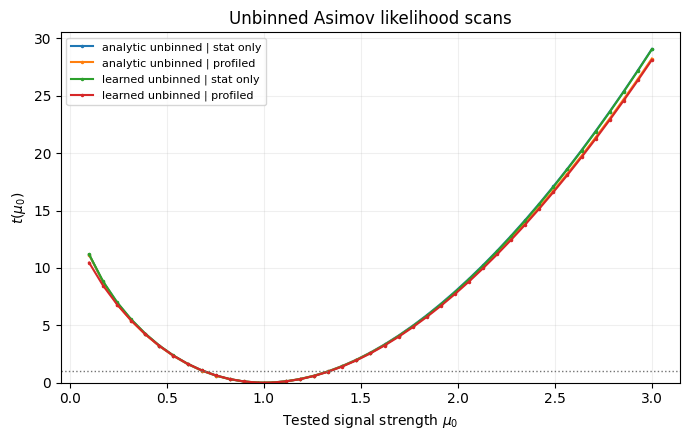

In [7]:
plot_scans(unbinned['scans'], 'Unbinned Asimov likelihood scans', '03_unbinned_scans.pdf');

### Check the numerical expectation itself

The next diagnostic evaluates the nominal-nuisance analytical Asimov
objective using the full integration sample and two disjoint halves.
The split is made **within each proposal stratum before selection**;
rejected events contribute zero to the uncertainty calculation.
Error bars estimate Monte Carlo integration uncertainty, not statistical
confidence intervals on \(\mu\). Half-sample agreement and small
estimated errors are checks on the numerical expectation; a precision
study should also increase the integration budget in a separate run.

,mu,q,standard_error,q_half_even,q_half_odd
0,0.1000,1.115884e+01,3.839797e-02,1.115161e+01,1.116608e+01
1,0.1725,8.780765e+00,3.178070e-02,8.776742e+00,8.784788e+00
2,0.2450,6.959229e+00,2.566750e-02,6.957001e+00,6.961456e+00
3,0.3175,5.473649e+00,2.029907e-02,5.472409e+00,5.474889e+00
4,0.3900,4.235729e+00,1.568967e-02,4.235018e+00,4.236439e+00
5,0.4625,3.199424e+00,1.179441e-02,3.198993e+00,3.199855e+00
6,0.5350,2.336626e+00,8.555013e-03,2.336344e+00,2.336907e+00
7,0.6075,1.628276e+00,5.913850e-03,1.628081e+00,1.628471e+00
8,0.6800,1.060467e+00,3.818157e-03,1.060331e+00,1.060602e+00
9,0.7525,6.224861e-01,2.220955e-03,6.223972e-01,6.225750e-01


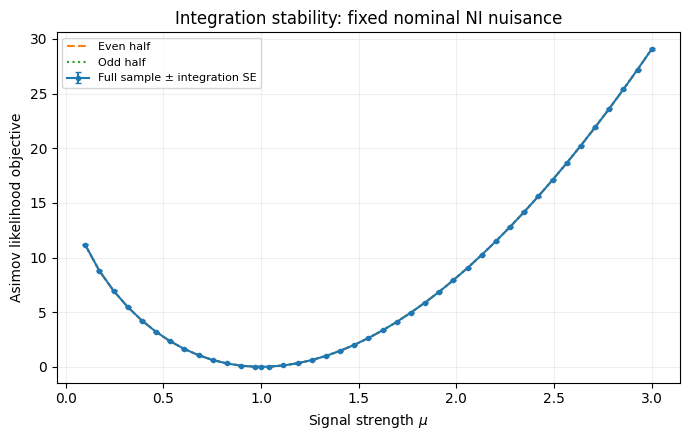

In [8]:
integration_check = unbinned["quadrature"].sort_values("mu")
display(integration_check)
fig, ax = plt.subplots()
ax.errorbar(integration_check["mu"], integration_check["q"],
            yerr=integration_check["standard_error"], fmt="o-", ms=3,
            capsize=2, label="Full sample ± integration SE")
ax.plot(integration_check["mu"], integration_check["q_half_even"], "--", label="Even half")
ax.plot(integration_check["mu"], integration_check["q_half_odd"], ":", label="Odd half")
ax.set(xlabel=r"Signal strength $\mu$", ylabel="Asimov likelihood objective",
       title="Integration stability: fixed nominal NI nuisance")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(ROOT / "plots" / "03_quadrature_stability.pdf", bbox_inches="tight")
plt.show()

In [9]:
for key, value in unbinned.items():
    if key not in ("scans", "quadrature"):
        print(key)
        display(value)

diagnostics


,model,systematics,mu_hat,alpha_NI_hat,nll,valid,edm
0,analytic unbinned,False,1.000000,0.000000e+00,4.222365e-14,True,2.060113e-17
1,analytic unbinned,True,1.000000,2.785373e-09,6.982343e-14,True,5.840445e-15
2,learned unbinned,False,1.004086,0.000000e+00,4.785680e-01,True,9.834268e-11
3,learned unbinned,True,1.004883,-2.350979e-02,4.742815e-01,True,2.313650e-09


The horizontal line at \(t=1\) is a visual likelihood-scale reference.
These Asimov curves alone do not demonstrate interval coverage or
establish Wilks' theorem at a boundary. The scan uses positive signal
strengths; the derivative of the \(\sqrt\mu\) model is singular at zero.
The default scan is \(0.1\le\mu\le3\); the fit domain is
\(0.001\le\mu\le4\). The lower fit bound is a numerical floor for
this regular interior demonstration, not an implementation of a
discovery test at the physical boundary \(\mu=0\).

Short smoke training may give visibly inaccurate learned curves or
invalid learned intensities. Such points are flagged and appear as gaps;
they do not count as successful learned-model closure. Inspect fit
validity and ratio diagnostics before increasing the training budget.

Next: **04_score_histograms.ipynb**.